# **1. Persiapan Lingkungan, Library, dan Autentikasi API**
Saya memulai langkah awal dengan menginstal dan memuat seluruh pustaka (library) yang dibutuhkan untuk manipulasi data, pemodelan, hingga deployment. Di sel ini, saya juga melakukan autentikasi ke Hugging Face dan Kaggle agar saya memiliki akses penuh untuk mengunduh dataset dan mengunggah model nantinya.

---

In [2]:
# Install semua library yang dibutuhkan di awal
!pip install -q xgboost scikit-learn pandas matplotlib huggingface_hub kaggle joblib imbalanced-learn

import os
import glob
import getpass
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import notebook_login, HfApi
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

print("=== 1. Autentikasi Hugging Face ===")
print("Pastikan Anda menggunakan token dengan akses 'WRITE'.")
notebook_login()

print("\n=== 2. Autentikasi Kaggle ===")
kaggle_user = input("Masukkan Username Kaggle Anda: ")
kaggle_key = getpass.getpass("Masukkan API Key Kaggle Anda: ")

# Mendaftarkan kredensial ke environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_user
os.environ['KAGGLE_KEY'] = kaggle_key

print("✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan!")

=== 1. Autentikasi Hugging Face ===
Pastikan Anda menggunakan token dengan akses 'WRITE'.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



=== 2. Autentikasi Kaggle ===
Masukkan Username Kaggle Anda: ripanripan
Masukkan API Key Kaggle Anda: ··········
✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan!


# **2. Akuisisi Dataset dan Analisis Eksploratif (EDA)**
Pada tahap ini, saya mengunduh dataset `mlg-ulb/creditcardfraud` langsung dari Kaggle ke dalam direktori kerja. Setelah data berhasil dimuat, saya melakukan analisis eksploratif singkat untuk meninjau struktur data serta memvisualisasikan distribusi kelas. Langkah ini krusial untuk memahami tingkat ketimpangan (*imbalance*) yang ekstrem antara transaksi normal dan *fraud*.

---

Masukkan format <username>/<nama-dataset> dari Kaggle (tekan Enter untuk default 'mlg-ulb/creditcardfraud'): 

⏳ Sedang mengunduh dataset: mlg-ulb/creditcardfraud dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
✅ Unduhan dan ekstraksi selesai di folder: creditcardfraud/
⏳ Memuat file dataset otomatis: creditcardfraud/creditcard.csv ...

✅ Dataset berhasil dimuat!

🔍 MELAKUKAN ANALISIS DATA (EDA)...
------------------------------
 - Normal: 284315 transaksi (99.827%)
 - Fraud: 492 transaksi (0.173%)


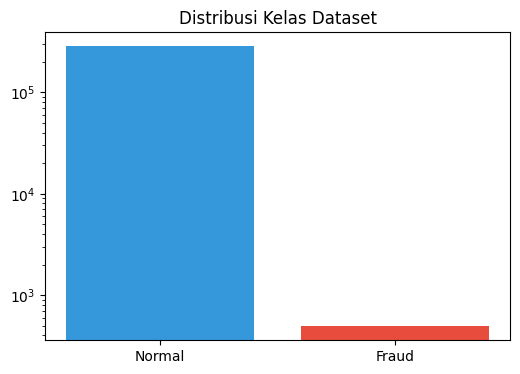

In [3]:
# Meminta input path dataset Kaggle
nama_dataset_kaggle = input("Masukkan format <username>/<nama-dataset> dari Kaggle (tekan Enter untuk default 'mlg-ulb/creditcardfraud'): ")
if not nama_dataset_kaggle:
    nama_dataset_kaggle = "mlg-ulb/creditcardfraud"

print(f"\n⏳ Sedang mengunduh dataset: {nama_dataset_kaggle} dari Kaggle...")
nama_folder = nama_dataset_kaggle.split('/')[-1]

try:
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(nama_dataset_kaggle, path=nama_folder, unzip=True)
    print(f"✅ Unduhan dan ekstraksi selesai di folder: {nama_folder}/")
except Exception as e:
    print(f"❌ Gagal mengunduh dataset. Error: {e}")

csv_files = glob.glob(os.path.join(nama_folder, '*.csv'))

if not csv_files:
    print(f"\n❌ Error Kritis: Tidak ada file CSV yang ditemukan di folder '{nama_folder}'.")
else:
    file_path = max(csv_files, key=os.path.getsize)
    print(f"⏳ Memuat file dataset otomatis: {file_path} ...")
    df = pd.read_csv(file_path)
    print("\n✅ Dataset berhasil dimuat!")

    target_col = 'Class' if 'Class' in df.columns else input("Ketikkan nama kolom target secara manual: ")

    print("\n🔍 MELAKUKAN ANALISIS DATA (EDA)...")
    print("-" * 30)
    distribusi = df[target_col].value_counts()
    label_names = {0: 'Normal', 1: 'Fraud'}

    for label_code, jumlah in distribusi.items():
        nama_label = label_names.get(label_code, f'Kelas {label_code}')
        persentase = (jumlah / len(df)) * 100
        print(f" - {nama_label}: {jumlah} transaksi ({persentase:.3f}%)")

    plt.figure(figsize=(6, 4))
    colors = ['#3498db', '#e74c3c']
    x_labels = [label_names.get(code, f'Kelas {code}') for code in distribusi.index]
    plt.bar(x_labels, distribusi.values, color=colors[:len(distribusi)])
    plt.title(f"Distribusi Kelas Dataset", fontsize=12)
    plt.yscale('log')
    plt.show()

# **3. Preprocessing dan Hybrid Resampling**
Untuk menjaga objektivitas evaluasi model, dataset dibagi menjadi data latih (*train set*) dan data uji (*test set*). Selain itu, proses *scaling* diterapkan menggunakan `RobustScaler` pada fitur yang memiliki perbedaan rentang nilai yang ekstrem (seperti waktu dan nominal transaksi).

Mengingat data sangat *imbalanced*, saya menerapkan teknik **Hybrid Resampling** pada data latih menggunakan kombinasi **SMOTE** (untuk memperbanyak sampel minoritas secara sintetis) dan **Random Undersampling** (untuk mengurangi sampel mayoritas).

---


⏳ Sedang melakukan proses Hybrid Resampling (SMOTE + Undersampling)...


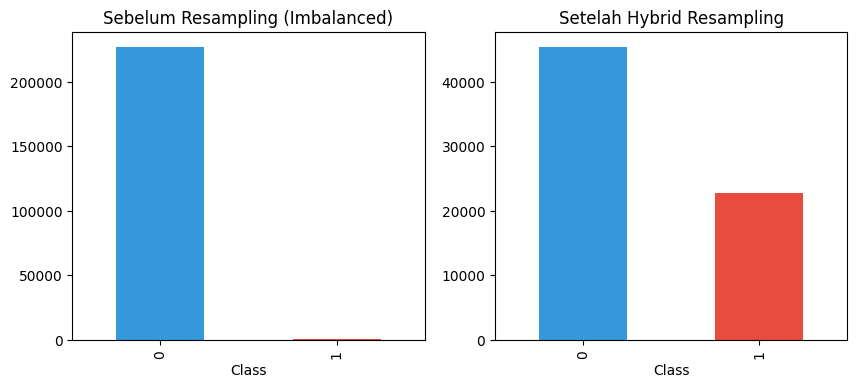

In [4]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Split data: 20% untuk data uji murni
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling pada fitur yang rentang nilainya ekstrem
scaler = RobustScaler()
if 'Time' in X_train.columns and 'Amount' in X_train.columns:
    X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
    X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# Penerapan Hybrid Resampling melalui Pipeline
over = SMOTE(sampling_strategy=0.1, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
pipeline_resample = Pipeline(steps=[('o', over), ('u', under)])

print("\n⏳ Sedang melakukan proses Hybrid Resampling (SMOTE + Undersampling)...")
X_train_resampled, y_train_resampled = pipeline_resample.fit_resample(X_train, y_train)

# Visualisasi perbandingan distribusi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title("Sebelum Resampling (Imbalanced)")
plt.subplot(1, 2, 2)
y_train_resampled.value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title("Setelah Hybrid Resampling")
plt.show()

# **4. Pelatihan Model dan Evaluasi Performa**
Pada tahap ini, model **Extra Trees Classifier** dilatih menggunakan data yang telah diseimbangkan (*resampled data*). Evaluasi performa kemudian diuji menggunakan **Data Uji Murni (Test Set)** yang tidak pernah melihat proses sintesis SMOTE, guna mendapatkan metrik akurasi deteksi *fraud* yang valid di skenario dunia nyata.

---

⏳ Menginisialisasi model Extra Trees...
⏳ Sedang melatih model dengan data yang sudah diseimbangkan...
✅ Model Extra Trees selesai dilatih!

⏳ Melakukan prediksi pada data Ujian Murni (Test Set)...

📊 HASIL EVALUASI MODEL:
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.71      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

-------------------------------------------------------


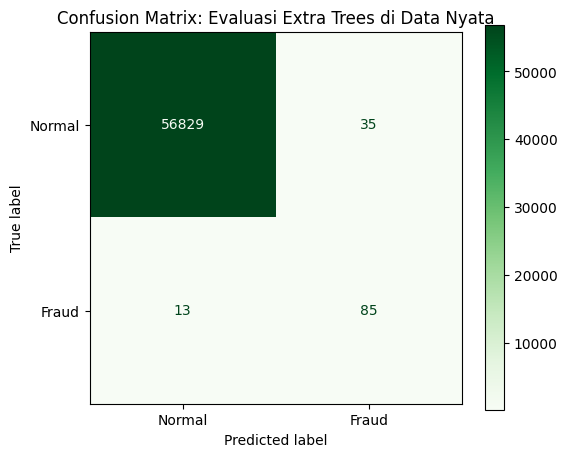

In [5]:
print("⏳ Menginisialisasi model Extra Trees...")
model_et = ExtraTreesClassifier(random_state=42, n_jobs=-1)

print("⏳ Sedang melatih model dengan data yang sudah diseimbangkan...")
model_et.fit(X_train_resampled, y_train_resampled)
print("✅ Model Extra Trees selesai dilatih!")

print("\n⏳ Melakukan prediksi pada data Ujian Murni (Test Set)...")
y_pred = model_et.predict(X_test)

print("\n📊 HASIL EVALUASI MODEL:")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print("-" * 55)

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Greens', values_format='d', ax=ax)
plt.title("Confusion Matrix: Evaluasi Extra Trees di Data Nyata", fontsize=12)
plt.show()

# **5. Pengecekan Stabilitas: Overfitting vs Underfitting**
Untuk memvalidasi ketangguhan model, saya membandingkan nilai **F1-Score** antara data latih (yang sudah di-*resample*) dan data uji. Ini krusial untuk memastikan model tidak hanya menghafal data sintesis buatan SMOTE, melainkan berhasil mengekstraksi pola yang mampu digeneralisasi.

In [6]:
print("\n⏳ Mengecek stabilitas performa model...")
# PENTING: Evaluasi train dilakukan pada X_train_resampled karena model dilatih dengan data tersebut
y_train_pred = model_et.predict(X_train_resampled)

# Menghitung F1-Score (Macro) dan Akurasi
train_f1 = f1_score(y_train_resampled, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_pred, average='macro')

train_acc = accuracy_score(y_train_resampled, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print("-" * 55)
print("📊 PERBANDINGAN PERFORMA (TRAIN vs TEST)")
print("-" * 55)
print(f"Akurasi  (Train Resampled) : {train_acc:.4f}  |  Akurasi  (Test Asli) : {test_acc:.4f}")
print(f"F1-Score (Train Resampled) : {train_f1:.4f}  |  F1-Score (Test Asli) : {test_f1:.4f}")
print("-" * 55)

# Analisis logis
selisih_f1 = train_f1 - test_f1

if selisih_f1 > 0.10: # Toleransi dilebarkan sedikit karena data latihnya sintetis (SMOTE)
    print("⚠️ KESIMPULAN: Indikasi OVERFITTING.")
    print("Model menghafal data resampled terlalu baik tetapi gagal menggeneralisasi data asli dengan sempurna.")
    print("Saran: Kurangi rasio SMOTE, batasi max_depth pohon, atau gunakan pruning.")
elif train_f1 < 0.70:
    print("⚠️ KESIMPULAN: Indikasi UNDERFITTING.")
    print("Model gagal mempelajari pola data.")
else:
    print("✅ KESIMPULAN: Model STABIL (GOOD FIT).")
    print("Perbedaan performa wajar. Model tangguh menangani data nyata meskipun dilatih dengan data sintetis.")


⏳ Mengecek stabilitas performa model...
-------------------------------------------------------
📊 PERBANDINGAN PERFORMA (TRAIN vs TEST)
-------------------------------------------------------
Akurasi  (Train Resampled) : 1.0000  |  Akurasi  (Test Asli) : 0.9992
F1-Score (Train Resampled) : 1.0000  |  F1-Score (Test Asli) : 0.8897
-------------------------------------------------------
⚠️ KESIMPULAN: Indikasi OVERFITTING.
Model menghafal data resampled terlalu baik tetapi gagal menggeneralisasi data asli dengan sempurna.
Saran: Kurangi rasio SMOTE, batasi max_depth pohon, atau gunakan pruning.


# **6. Analisis Fitur dan Deployment (Hugging Face)**
Sebagai langkah akhir menuju *production*, model diekstrak untuk melihat fitur paling dominan. Setelah itu, model beserta objek skalanya (*scaler*) digabung ke dalam satu bundel (menggunakan `joblib`) dan diunggah ke repositori **Hugging Face** agar siap diakses melalui API.

---

🔍 MENGANALISIS FEATURE IMPORTANCE...


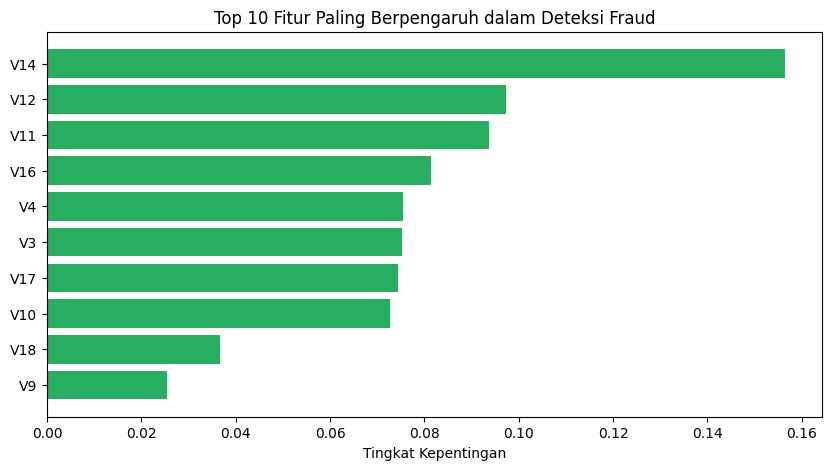


📦 PACKAGING MODEL & SCALER...

☁️ MENGUNGGAH KE HUGGING FACE HUB...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ection_et_bundle_v1.0.pkl:  85%|########4 | 24.0MB / 28.3MB            


✅ BINGO! Model berhasil diunggah ke: https://huggingface.co/Ripanrz/credit-card-fraud-et-v1.0


In [7]:
print("🔍 MENGANALISIS FEATURE IMPORTANCE...")
importances = model_et.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_imp_df.head(10)['Feature'][::-1], feature_imp_df.head(10)['Importance'][::-1], color='#27ae60')
plt.title('Top 10 Fitur Paling Berpengaruh dalam Deteksi Fraud')
plt.xlabel('Tingkat Kepentingan')
plt.show()

print("\n📦 PACKAGING MODEL & SCALER...")
pipeline_bundle = {'scaler': scaler, 'model': model_et}
nama_file_bundle = 'fraud_detection_et_bundle_v1.0.pkl'
joblib.dump(pipeline_bundle, nama_file_bundle)

print("\n☁️ MENGUNGGAH KE HUGGING FACE HUB...")
repo_id = "Ripanrz/credit-card-fraud-et-v1.0"

try:
    api = HfApi()
    api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
    api.upload_file(
        path_or_fileobj=nama_file_bundle,
        path_in_repo=nama_file_bundle,
        repo_id=repo_id,
        repo_type="model"
    )
    print(f"\n✅ BINGO! Model berhasil diunggah ke: https://huggingface.co/{repo_id}")
except Exception as e:
    print(f"\n❌ Gagal mengunggah ke Hugging Face. Error: {e}")